# ESM2 pipeline

Functionality:
- Preprocess phylogeny aware pathogen epitope residue-level labelled polypeptide sequences 
- Pipeline 1: generate embeddings for lower level data using base ESM2 models. Use these embeddings to train a 2-layer neural network classifier. Generate predictions using target data.
- Pipeline 2: fine-tune all ESM2 model weights using higher level data. Use the the fine tuned model to generate embeddings for the lower level data and to then train the classifer.
Generate predictions using target data. 
- Pipeline 3: use parameter-efficient fine-tuning - Low Rank Adaption (LoRA) with higher level data to update adapter weights that are added to the base ESM2 model. Use the PEFT-tuned
model to generate embeddings for the lower level data and to train the classifier. Generate predictions using target data.
- Save validation results and target level predictions to csv.


In [6]:
# Dependencies and libraries
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import torch.nn.functional as F
from torch.nn.utils.rnn import pad_sequence
import torch.optim as optim

from transformers import AutoModel, AutoTokenizer, AutoModelForTokenClassification, TrainingArguments, Trainer, DataCollatorForTokenClassification, DataCollatorWithPadding
from peft import LoraModel, LoraConfig, inject_adapter_in_model
import datasets

import esm

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math

from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold, train_test_split
from sklearn.metrics import accuracy_score, f1_score, recall_score, precision_score, matthews_corrcoef, roc_auc_score, confusion_matrix

from pathlib import Path
from pathlib import PurePosixPath
import s3fs

In [9]:
# ESM checkpoints
ESM = ['facebook/esm2_t48_15B_UR50D',
        'facebook/esm2_t36_3B_UR50D',
        'facebook/esm2_t33_650M_UR50D',
        'facebook/esm2_t30_150M_UR50D',
        'facebook/esm2_t12_35M_UR50D',
        'facebook/esm2_t6_8M_UR50D']

In [10]:
# Define checkpoint to be used
checkpoint = ESM[5]

In [11]:
if torch.cuda.is_available():
    device = 'cuda'
else:
    device = 'cpu'

print(device)

cuda


In [12]:

# ------------------ INPUT ------------------
# Select no_fine_tuning = True if generating embeddings from the model with pre-trained weights (pipeline 1)
no_fine_tuning = False
# -------------------------------------------


# ------------------ INPUT ------------------
# Select full fine tuning (pipeline 2), change to False if using LoRA (pipeline 3)
full_fine_tuning = True
# -------------------------------------------


if no_fine_tuning:
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    model = AutoModel.from_pretrained(checkpoint)

num_labels = 2

#load ESM2 models
def load_esm_model_classification(checkpoint, num_labels, full):  
    
    tokenizer = AutoTokenizer.from_pretrained(checkpoint)
    
    model = AutoModelForTokenClassification.from_pretrained(checkpoint, num_labels=num_labels)
    
    if full == True:
        return model, tokenizer 
    
    else:
        peft_config = LoraConfig(r=4, lora_alpha=1, bias="all", target_modules=["query","key","value","dense"])
        
        model = inject_adapter_in_model(peft_config, model)
        
        # Unfreeze the prediction head for LoRA (not required for full fine-tuning as head automatically unfrozen)
        for (param_name, param) in model.classifier.named_parameters():
                    param.requires_grad = True  
        
        return model, tokenizer

if no_fine_tuning == False:
    model, tokenizer = load_esm_model_classification(checkpoint, num_labels, full_fine_tuning)

model.to(device)

Some weights of EsmForTokenClassification were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


EsmForTokenClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1026, 320, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (LayerNorm): LayerNorm((320,), eps=1e-05, el

In [22]:
# Define run type to add to file save name
if no_fine_tuning == True:
    run = 'base'
elif no_fine_tuning == False and full_fine_tuning == False:
    run = 'LoRA'
elif no_fine_tuning == False and full_fine_tuning == True:
    run = 'full'

# ------------------ INPUT ------------------
# S3 bucket name
S3 = 's3://esm2-s3-bucket/datasets/Orthopoxvirus/'
# -------------------------------------------


In [27]:
fs = s3fs.S3FileSystem()

files = fs.ls(S3)

def select_datasets(files):
    # Define higher, lower and test data
    lower_level = None
    higher_level = None
    target = None

    for file in files:
        name = PurePosixPath(file).name

        if 'Lower' in name:
            lower_level = "s3://" + file
        elif 'Higher' in name:
            higher_level = "s3://" + file
        elif 'Target' in name:
            target = "s3://" + file

    return lower_level, higher_level, target

# # Assign to variables for automatic csv selection in code
lower_level, higher_level, target = select_datasets(files)


### Sliding window 

- Check whether a sequence is greater than 1024 residues in length
- If > 1024, create copy of sequence
- Create segments

In [28]:
def sliding_window(df, window_size=1024, stride=512):
    """
    Function to create 1024 length splits for proteins >1024 in length, using stride length of 512
    Inserts new splits into a datatable with split suffix
    """
    rows = []
    
    for _, row in df.iterrows():
        seq = row['sequence']
        seq_len = len(seq)
        
        if seq_len <= window_size:
            rows.append(row.copy())
            continue
            
        start = 0
        split = 1
        while start < seq_len:
            # End slicing variable
            end = start + window_size

            # Create copy of the row
            new_row = row.copy()
            # Slice amino acid sequence by start end index
            new_row['sequence'] = seq[start:end]
            
            # Slice columns containing lists
            for col in ['label', 'position']:
                new_row[col] = row[col][start:end]

            # Add split suffix to Info_protein_id
            new_row['Info_protein_id'] = str(new_row['Info_protein_id']) + '_' + str(split) 
            # Append window to row list 
            rows.append(new_row)
            
            # Stop after the final window
            if end >= seq_len:
                break
                
            start += stride
            split += 1
            
    return pd.DataFrame(rows).reset_index(drop=True)

In [29]:
# Function to delete rows with all unlabelled residues
def delete_unlabelled_rows(df):
    return df[df['label'].apply(lambda labels: 0 in labels or 1 in labels)].reset_index(drop=True)

### Base embedder

In [30]:
def preprocess_for_baseline_embedder(lower_level, generate_cv_splits=True):# Preprocess training data
    df_lower_stacked = pd.read_csv(lower_level)
    
    # Mask n/a values with -100 
    df_lower_stacked['Class'] = df_lower_stacked['Class'].fillna(-100).astype('int32')
    df_lower_stacked['Class'] = df_lower_stacked['Class'].replace(-1, 0)
    
    # Sort values before aggregation
    df_lower = df_lower_stacked.sort_values(['Info_protein_id', 'Info_pos'])
    
    # Aggregate columns for wide format
    df_lower = df_lower.groupby(['Info_protein_id','Info_group', 'Info_split'], as_index=False).agg(
        sequence=('Info_AA', ''.join), 
        label=('Class', list), 
        position=('Info_pos', list))
    
    # Apply sliding window
    df_lower = sliding_window(df_lower)
    
    # Delete unlabelled rows
    df_lower = delete_unlabelled_rows(df_lower)
    
    if generate_cv_splits == True:
        
        # Create train / validation splits using the info split column
        cv_1_train = df_lower[df_lower['Info_split'] != 'split_01_20'].reset_index()
        cv_1_val = df_lower[df_lower['Info_split'] == 'split_01_20'].reset_index()
        
        cv_2_train = df_lower[df_lower['Info_split'] != 'split_02_20'].reset_index()
        cv_2_val = df_lower[df_lower['Info_split'] == 'split_02_20'].reset_index()
        
        cv_3_train = df_lower[df_lower['Info_split'] != 'split_03_20'].reset_index()
        cv_3_val = df_lower[df_lower['Info_split'] == 'split_03_20'].reset_index()
        
        cv_4_train = df_lower[df_lower['Info_split'] != 'split_04_20'].reset_index()
        cv_4_val = df_lower[df_lower['Info_split'] == 'split_04_20'].reset_index()
        
        cv_5_train = df_lower[df_lower['Info_split'] != 'split_05_20'].reset_index()
        cv_5_val = df_lower[df_lower['Info_split'] == 'split_05_20'].reset_index()
    
        return cv_1_train, cv_1_val, cv_2_train, cv_2_train, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val

    else:
        return df_lower_stacked, df_lower

In [31]:
# Create custom dataset class - add to separate file and import
class SequenceDataset(torch.utils.data.Dataset):
    
    def __init__(self, df):
        self.protein_id = df['Info_protein_id']
        self.sequence = df['sequence']
        self.position = df['position']
        self.labels = df['label']
        
    def __len__(self):
        return len(self.sequence)
        
    def __getitem__(self, idx):
        return {
            'protein_id': self.protein_id.iloc[idx],
            'sequence': self.sequence.iloc[idx],
            'position': self.position.iloc[idx],
            'label': self.labels.iloc[idx]
        }

def collate_fn(batch):
    """
    Function to create a custom collator to maintain length of items within the batch
    """
    return {
        'protein_id': [x['protein_id'] for x in batch],
        'sequence': [x['sequence'] for x in batch],
        'position': [x['position'] for x in batch],
        'label': [x['label'] for x in batch]
    }

def batch_create(dataset, tokenizer, model): 
    """
    Function to create a DataLoader instance using the the custom collate function
    """

    # Create a DataLoader instance using the cv dataset and the custom collate function
    loader = DataLoader(
        dataset,
        batch_size=16,
        shuffle=False,
        collate_fn=collate_fn
    )
    
    emb_output_list = []
    
    # Loop through each batch of tensors and apply tokenisation to each sequence
    for batch in loader:
        
        inputs = tokenizer(
            batch['sequence'],
            padding=True,
            truncation=False,
            return_tensors='pt'
        )
        
        inputs = {k: v.to(device) for k, v in inputs.items()}
          
        if no_fine_tuning == True:
            
            # Freeze model weights and calculate embeddings 
            with torch.inference_mode():

                # Use the base model to generate embeddings
                outputs = model(**inputs)
                embeddings = outputs.last_hidden_state[:, 1:-1, :].cpu() # Slice embeddings to remove start and end CLS/EOS tokens   

        else:
            # Freeze model weights and calculate embeddings 
            with torch.no_grad():
                
                # Use fine tuned model to generate embeddings
                outputs = model.esm(**inputs)
                embeddings = outputs.last_hidden_state[:, 1:-1, :].cpu() # Slice embeddings to remove start and end CLS/EOS tokens
        
        # Convert labels to tensors 
        labels = [torch.tensor(x) for x in batch['label']]

        # Pad each label to the size of the largest embedding within the batch
        labels = pad_sequence(labels, batch_first=True, padding_value=-100)

        # Append the embeddings, label and masks per batch to an output list 
        emb_output_list.append({
            'embeddings': embeddings,
            'labels': labels
        })

    return emb_output_list

In [32]:
# Create datasets
def baseline_embedder_create_datasets(cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val):
    train_datasets = {
        1:SequenceDataset(cv_1_train),
        2:SequenceDataset(cv_2_train), 
        3:SequenceDataset(cv_3_train),
        4:SequenceDataset(cv_4_train),
        5:SequenceDataset(cv_5_train)    
    }
    
    val_datasets = {
        1:SequenceDataset(cv_1_val),
        2:SequenceDataset(cv_2_val), 
        3:SequenceDataset(cv_3_val),
        4:SequenceDataset(cv_4_val),
        5:SequenceDataset(cv_5_val)    
    }
    
    # Create train batches
    train_loaded = {}
    
    for key, value in train_datasets.items():
        batched = batch_create(value, tokenizer, model)
        train_loaded[key] = batched
    
    # Create val batches
    val_loaded = {}
    
    for key, value in val_datasets.items():
        batched = batch_create(value, tokenizer, model) 
        val_loaded[key] = batched

    return train_loaded, val_loaded

# Generate splits (splits will also be used to train the classification head for fine tuning pipelines)
cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val = preprocess_for_baseline_embedder(lower_level)

# Create base model embeddings and preprocess labels
if no_fine_tuning == True:
    train_loaded, val_loaded = baseline_embedder_create_datasets(cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val)


### Fine Tuning

- Fine tune using higher level data
- Training will use LoRA if 'full_fine_tuning = False' at top of notebook

In [33]:
def preprocess_csv(csv_file):
    preprocessed_df = pd.read_csv(csv_file)

    # Mask n/a values with -100 
    preprocessed_df['Class'] = preprocessed_df['Class'].fillna(-100).astype('int32')
    preprocessed_df['Class'] = preprocessed_df['Class'].replace(-1, 0)
    
    # Sort values before aggregation
    preprocessed_df = preprocessed_df.sort_values(['Info_protein_id', 'Info_pos'])
    
    # Aggregate columns for wide format
    preprocessed_df = preprocessed_df.groupby(['Info_protein_id','Info_group', 'Info_split'], as_index=False).agg( 
        sequence=('Info_AA', ''.join), 
        label=('Class', list), 
        position=('Info_pos', list))

    # Apply sliding window
    preprocessed_df = sliding_window(preprocessed_df)

    # Delete unlabelled rows
    preprocessed_df = delete_unlabelled_rows(preprocessed_df)

    # preprocessed_df = preprocessed_df.sample(frac=0.01)

    return preprocessed_df

def preprocess(data):
    """
    Preprocess each df row to tokenise the sequences and pad labels to match max length
    """
    inputs = tokenizer(
            data['sequence'],
            padding='max_length',
            truncation=True, 
            max_length=1026,
        )
    
    labels = data['label']

    # Remove first and last special tokens for tokens and attention mask
    input_ids = inputs['input_ids'][1:-1]
    attn_mask = inputs['attention_mask'][1:-1]

    # Pad labels to max length
    labels = labels + ([-100] * (1024 - len(labels)))

    return {'input_ids': input_ids,
            'attention_mask': attn_mask,
            'labels': labels}

if no_fine_tuning == False:

    # Load and preprocess dataframe
    df_higher = preprocess_csv(higher_level)

    train_splits = {}
    val_splits = {}

    for fold in range(1, 6):
        split = f'split_{fold:02d}_20'

        train_splits[fold] = (df_higher[df_higher['Info_split'] != split].reset_index(drop=True))

        val_splits[fold] = (df_higher[df_higher['Info_split'] == split].reset_index(drop=True))

    # Final model: use all labelled data
    train_splits['final'] = df_higher.reset_index(drop=True)

    # No validation set for the final model
    val_splits['final'] = None

    train_datasets = {}
    val_datasets = {}

    for key, df in train_splits.items():
        train_datasets[key] = (datasets.Dataset.from_pandas(df).map(preprocess, remove_columns=df.columns.tolist()))

    for key, df in val_splits.items():
        if df is not None:
            val_datasets[key] = (datasets.Dataset.from_pandas(df).map(preprocess, remove_columns=df.columns.tolist()))
        else:
            val_datasets[key] = None

    data_collator = DataCollatorForTokenClassification(tokenizer=tokenizer)


/tmp/ipykernel_3279/1685102025.py:2: DtypeWarning: Columns (0: Info_protein_id) have mixed types. Specify dtype option on import or set low_memory=False.
  preprocessed_df = pd.read_csv(csv_file)


Map:   0%|          | 0/7129 [00:00<?, ? examples/s]

Map:   0%|          | 0/7169 [00:00<?, ? examples/s]

Map:   0%|          | 0/7746 [00:00<?, ? examples/s]

Map:   0%|          | 0/7853 [00:00<?, ? examples/s]

...

Map:   0%|          | 0/2115 [00:00<?, ? examples/s]

Map:   0%|          | 0/2075 [00:00<?, ? examples/s]

Map:   0%|          | 0/1498 [00:00<?, ? examples/s]

Map:   0%|          | 0/1391 [00:00<?, ? examples/s]

Map:   0%|          | 0/2165 [00:00<?, ? examples/s]

In [34]:
# Save a table of the number and percent of trainable parameters
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

total_params = sum(p.numel() for p in model.parameters())
    
trainable_percent = trainable_params/total_params * 100

parameter_summary = {
    'trainable_params': trainable_params,
    'total_params': total_params,
    'trainable_percent': trainable_percent}

parameter_summary = pd.DataFrame([parameter_summary])

parameter_summary.to_csv(f'{S3}{checkpoint[9:]}_{run}_trainable_parameters_summary.csv')

In [ ]:
# Store results
train_logs = []
eval_logs = []
summary_logs = []

final_train_logs = []
final_summary_logs = []

# Define Trainer parameters
def compute_metrics(p):
    
    # Separate logits and labels
    pred, labels = p    
    
    # Return index of higher position (neg or positive residue) per row
    max_pred = np.argmax(pred, axis=-1)

    # Calculate probabilites to be used for AUC
    probs = torch.softmax(torch.tensor(pred), dim=-1)
    probs = probs[:, :, 1]

    # Create mask for unlabelled positions
    mask = labels != -100

    # Calculate metrics
    accuracy = accuracy_score(y_true=labels[mask], y_pred=max_pred[mask])
    recall = recall_score(y_true=labels[mask], y_pred=max_pred[mask])
    precision = precision_score(y_true=labels[mask], y_pred=max_pred[mask])
    f1 = f1_score(y_true=labels[mask], y_pred=max_pred[mask])
    mcc = matthews_corrcoef(y_true=labels[mask], y_pred=max_pred[mask])
    auc = roc_auc_score(y_true=labels[mask], y_score=probs[mask])

    return {'accuracy': accuracy, 'precision': precision, 'recall': recall, 'f1': f1, 'mcc': mcc, 'auc': auc}

num_fine_tune_epochs = 1 # 10 in Nature peft paper

if no_fine_tuning == False:
    
    for fold in range(1, 6):

        # Load fresh model for each train/validation fold
        model, tokenizer = load_esm_model_classification(checkpoint, num_labels, full_fine_tuning)        
        
        training_args = TrainingArguments(
            output_dir=f'{S3}{checkpoint[9:]}_{run}_training_arguments_val',
            # learning_rate=2e-5,
            per_device_train_batch_size=4, # Match to Nature peft paper
            gradient_accumulation_steps=2, # Match to Nature peft paper
            # per_device_train_batch_size=16,
            per_device_eval_batch_size=4,
            # fp16=False, # Change precision to match Nature paper
            num_train_epochs=num_fine_tune_epochs,
            learning_rate=3e-4, # Match to Nature peft paper
            seed=42, # Match to Nature peft paper
            eval_strategy='epoch', # Update from epoch
            # eval_steps=500, 
            # save_strategy='epoch',
            # save_steps=500,
            logging_strategy='epoch', # Steps?
            load_best_model_at_end=False,
            metric_for_best_model='auc',
            greater_is_better=True
        )
        
        trainer = Trainer(
            model=model,
            args=training_args,
            train_dataset=train_datasets[fold],
            eval_dataset=val_datasets[fold],
            processing_class=tokenizer,
            data_collator=data_collator,
            compute_metrics=compute_metrics,
        )
                
        trainer.train()
        
        metrics = trainer.evaluate()

        metrics['fold'] = fold

        for log in trainer.state.log_history:
            log['fold'] = fold
        
            if 'eval_loss' in log:
                eval_logs.append(log)
            elif 'grad_norm' in log:
                train_logs.append(log)
            elif 'train_runtime' in log:
                summary_logs.append(log)
        
        eval_log_df = pd.DataFrame(eval_logs)
        train_log_df = pd.DataFrame(train_logs)
        summary_df = pd.DataFrame(summary_logs)
        
                
    # Train on full data -----------------------

    # Load fresh model
    model, tokenizer = load_esm_model_classification(checkpoint, num_labels, full_fine_tuning)
    
    training_args = TrainingArguments(
        output_dir = f'/home/ubuntu/output/{checkpoint[9:]}_{run}_finetune_training_final',
        # learning_rate=2e-5,
        per_device_train_batch_size=4, # Match to Nature peft paper
        gradient_accumulation_steps=2, # Match to Nature peft paper
        per_device_eval_batch_size=4,
        num_train_epochs=num_fine_tune_epochs,
        learning_rate=3e-4, # Match to Nature peft paper
        seed=42, # Match to Nature peft paper
        eval_strategy='no', # Update from epoch
        save_strategy='epoch',
        logging_strategy='epoch',
        load_best_model_at_end=False,
    )
    
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=train_datasets['final'],
        processing_class=tokenizer,
        data_collator=data_collator,
    )    
    
    trainer.train()

    for log in trainer.state.log_history:
    
        if "loss" in log:
            final_train_logs.append(log)
        elif "train_runtime" in log:
            final_summary_logs.append(log)
    
    # Convert to DataFrames
    final_train_log_df = pd.DataFrame(final_train_logs)
    final_summary_df = pd.DataFrame(final_summary_logs)

    model_output = f'/home/ubuntu/output/{checkpoint[9:]}_{run}_fine_tuned_model'

    # Explicitly save model
    trainer.save_model(model_output)
    

# Save validation metrics
eval_log_df.to_csv(f'{S3}{checkpoint[9:]}_{run}_cv_validation_metrics.csv', index=False)
train_log_df.to_csv(f'{S3}{checkpoint[9:]}_{run}_cv_train_metrics.csv', index=False)
summary_df.to_csv(f'{S3}{checkpoint[9:]}_{run}_cv_eval_log.csv', index=False)

# Save final logs
final_train_log_df.to_csv(f'{S3}{checkpoint[9:]}_{run}_final_training_log.csv', index=False)
final_summary_df.to_csv(f'{S3}{checkpoint[9:]}_{run}_final_training_summary.csv', index=False)

Some weights of EsmForTokenClassification were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss,Accuracy,Precision,Recall,F1,Mcc,Auc
0,0.457700,0.478983,0.743963,0.479474,0.861123,0.615974,0.489501,0.832487


Some weights of EsmForTokenClassification were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['classifier.bias', 'classifier.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


Epoch,Training Loss,Validation Loss


### Train classification head 

- Inputs: lower level data

In [76]:
# Load full fine tuned model (to save on completing full fine-tuning)
if no_fine_tuning == False:
    model = AutoModelForTokenClassification.from_pretrained(f'/home/ubuntu/output/{checkpoint[9:]}_{run}_fine_tuned_model')
    model.eval()

### Generate embeddings for lower level data using the fine-tuned embedder

- Skips if base embedder used

In [44]:
model.to(device)

if no_fine_tuning == False:
    train_loaded, val_loaded = baseline_embedder_create_datasets(cv_1_train, cv_1_val, cv_2_train, cv_2_val, cv_3_train, cv_3_val, cv_4_train, cv_4_val, cv_5_train, cv_5_val)

In [45]:
# Create training data and lower stacked for weighted loss function for training the classifier without cross validation
df_lower_stacked, df_lower = preprocess_for_baseline_embedder(lower_level, generate_cv_splits=False)

full_trained_dataset = SequenceDataset(df_lower)

full_train_batched = batch_create(full_trained_dataset, tokenizer, model)

In [46]:
# # Classification head
class PerResidueClassifier(nn.Module):
    def __init__(self):
        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(320, 128),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(128, 2),
        )

    def forward(self, x):
        return self.net(x)

In [47]:
# Determine frequency of positive vs negative labels to be used to weight the loss function
neg_class = len(df_lower_stacked[df_lower_stacked['Class'] == 0])
pos_class = len(df_lower_stacked[df_lower_stacked['Class'] == 1])

# Total labelled 
total = neg_class + pos_class

# Set the weight as the inverse proportion of the tota
neg_weight = torch.tensor([total/(2*neg_class)])
pos_weight = torch.tensor([total/(2*pos_class)])

# Concat tensors 
weight = torch.cat([neg_weight, pos_weight])
weight = weight.to(device)

In [49]:
# Instantiate classifier
clf = PerResidueClassifier()
# Move to CUDA
clf = clf.to(device)

# Instantiate cross-entropy loss function, ignores positions with mask -100
loss_fcn = nn.CrossEntropyLoss(weight=weight, ignore_index=-100) 

def train_one_epoch(model, train_dataloader, optimiser, loss_function):    

    # Put the clf in training mode
    model.train()
    
    running_loss = 0
    
    train_preds = []
    train_labels = []
    
    for batch in train_dataloader:
        inputs = batch['embeddings'].to(device)
        labels = batch['labels'].to(device)
        
        # Zero model gradients per batch
        optimiser.zero_grad()
        
        # Caluclate logits by passing embeddings through the classifier
        outputs = model(inputs)
        
        # Compute loss and gradients        
        loss = loss_function(outputs.reshape(-1, 2), labels.reshape(-1))

        # Calculate the gradients through the network
        loss.backward()

        # Adjust learning weights
        optimiser.step()

        # Add the loss to a running counter
        running_loss += loss.item()

        # Predicted labels, assign pos or negative based on argmax of the pos / neg class logits, flatten
        train_preds.append(torch.argmax(outputs, dim=-1).reshape(-1))
        train_labels.append(labels.reshape(-1))

    # Concat the batched tensors to lists
    train_preds = torch.cat(train_preds)
    train_labels = torch.cat(train_labels)

    # Create mask for calculating metrics only on labelled residues
    mask = train_labels != -100

    train_preds = train_preds[mask].cpu().numpy()
    train_labels = train_labels[mask].cpu().numpy()

    metrics = {
        'loss': running_loss / len(train_dataloader),
        'accuracy': accuracy_score(
            train_labels,
            train_preds)
    }

    return metrics


def val_one_epoch(model, val_dataloader, loss_function):
    
    # Put the classifier into evaluation mode
    model.eval()

    running_loss = 0

    val_preds = []
    val_labels = []
    val_probs = []
    
    # Training loop 
    with torch.no_grad():
        for batch in val_dataloader:
            inputs = batch['embeddings'].to(device)
            labels = batch['labels'].to(device)

            # Caluclate logits by passing embeddings through the classifier
            outputs = model(inputs)
    
            # Compute loss and gradients        
            loss = loss_function(outputs.reshape(-1, 2), labels.reshape(-1))
    
            # Add the loss to a running counter
            running_loss += loss.item()
    
            # Predicted labels, assign pos or negative based on argmax of the pos / neg class logits, flatten and append
            val_preds.append(torch.argmax(outputs, dim=-1).reshape(-1))
            val_labels.append(labels.reshape(-1))
            
            # Calculate probabilites to be used for AUC
            probs = torch.softmax(outputs, dim=-1)
            pos_probs_flat = probs[:, :, 1].reshape(-1)
            val_probs.append(pos_probs_flat)

    # Concat the batched tensors in the lists 
    val_preds = torch.cat(val_preds)
    val_labels = torch.cat(val_labels) 
    val_probs = torch.cat(val_probs)

    mask = val_labels != -100

    # Apply mask while still tensors
    val_preds = val_preds[mask].cpu().numpy()
    val_labels = val_labels[mask].cpu().numpy()
    val_probs = val_probs[mask].cpu().numpy()

    # Calculate validation metrics
    metrics = {
        'loss': running_loss / len(val_dataloader),
        'accuracy': accuracy_score(val_labels, val_preds),
        'precision': precision_score(val_labels, val_preds),
        'recall': recall_score(val_labels, val_preds),
        'f1': f1_score(val_labels, val_preds),
        'mcc': matthews_corrcoef(val_labels, val_preds),
        'auc': roc_auc_score(val_labels, val_probs)
    }

    return metrics


def train_classifier(model,
    train_dataloader,
    val_dataloader,
    loss_function,
    epochs=20):

    logs = []

    for key in train_dataloader.keys():

        model = PerResidueClassifier().to(device)

        optimiser = optim.AdamW(model.parameters(), lr=0.001)
        
        best_auc = 0

        for epoch in range(epochs):

            train_metrics = train_one_epoch(model, train_dataloader[key], optimiser, loss_function)
            
            val_metrics = val_one_epoch(model, val_dataloader[key], loss_function)

            logs.append({
                'fold': key,
                'epoch': epoch + 1,
                'train_loss': train_metrics['loss'],
                'train_acc': train_metrics['accuracy'],
                'val_loss': val_metrics['loss'],
                'val_acc': val_metrics['accuracy'],
                'val_precision': val_metrics['precision'],
                'val_recall': val_metrics['recall'],
                'val_f1': val_metrics['f1'],
                'val_mcc': val_metrics['mcc'],
                'val_auc': val_metrics['auc'],
            })           

    history = pd.DataFrame(logs)
            
    return history

def train_final_classifier(model,
    train_dataloader,
    loss_function,
    epochs=20):

    logs = []
    
    model = model.to(device)
    
    optimiser = torch.optim.AdamW(model.parameters(), lr=0.001)
    
    for epoch in range(epochs):
        
        train_metrics = train_one_epoch(model, train_dataloader, optimiser, loss_function)

        logs.append({
            'epoch': epoch + 1,
            'train_loss': train_metrics['loss'],
            'train_acc': train_metrics['accuracy']
        })
    
    # Save final model
    model_path = f'/home/ubuntu/output/{checkpoint[9:]}_{run}_final_classifier.pt'

    with fs.open(model_path, 'wb') as f:
        torch.save(            {
                'model_state_dict': model.state_dict(),
                'epochs': epochs
            },f)
    
    history = pd.DataFrame(logs)
            
    return history

clf_trained = train_classifier(clf, train_loaded, val_loaded, loss_fcn, epochs=20)

In [68]:
# Calculate average validation metrics per epoch 
clf_validation_avg_metrics = clf_trained.groupby(['epoch'])[[
    'train_loss', 
    'train_acc', 
    'val_loss', 
    'val_acc', 
    'val_precision', 
    'val_recall', 
    'val_f1', 
    'val_mcc', 
    'val_auc']].agg(['mean', 'std'])

# Save to csv
clf_validation_avg_metrics.to_csv(f'{S3}{checkpoint[9:]}_{run}_clf_validation_avg_metrics.csv')

# Validation metrics per epoch by fold
clf_validation_metrics = clf_trained[[
    'epoch',
    'fold',
    'train_loss',
    'train_acc',
    'val_loss',
    'val_acc',
    'val_precision',
    'val_recall',
    'val_f1',
    'val_mcc',
    'val_auc']]

# Save to csv
clf_validation_avg_metrics.to_csv(f'{S3}{checkpoint[9:]}_{run}_clf_validation_metrics_by_fold.csv')

best_auc_epochs = clf_validation_avg_metrics['val_auc'].idxmax(axis=0)['mean']

clf_validation_avg_metrics

train_loss           train_acc            val_loss             val_acc  \
            mean       std      mean       std      mean       std      mean   
epoch                                                                          
1       0.679006  0.017768  0.569135  0.137591  0.729006  0.075019  0.644408   
2       0.628057  0.015537  0.700129  0.045501  0.720500  0.072297  0.654690   
3       0.611448  0.016371  0.703638  0.048399  0.714029  0.064944  0.656355   
4       0.604205  0.016609  0.707931  0.046748  0.708735  0.059097  0.656151   
5       0.599740  0.016040  0.707288  0.039492  0.704334  0.057600  0.654870   
6       0.594673  0.017284  0.709569  0.035258  0.702253  0.060328  0.653997   
7       0.589890  0.017298  0.709306  0.031596  0.703860  0.066769  0.654273   
8       0.585953  0.018207  0.710409  0.030249  0.706481  0.075569  0.655647   
9       0.581387  0.019400  0.711671  0.032056  0.709650  0.085177  0.657550   
10      0.576897  0.020664  0.712416  0.032543  0.712817  0.094648  0.660697   
11      0.572465  0.020160  0.715595  0.029839  0.716511  0.103970  0.662105   
12      0.567680  0.022704  0.718812  0.029950  0.720916  0.112559  0.664307   
13      0.565332  0.022386  0.719162  0.030778  0.725325  0.120949  0.665728   
14      0.560008  0.023042  0.719515  0.028998  0.730638  0.129145  0.665706   
15      0.555951  0.024825  0.722607  0.026265  0.735979  0.137894  0.666083   
16      0.553194  0.025130  0.722983  0.028866  0.739773  0.147585  0.668190   
17      0.549112  0.026049  0.726622  0.027949  0.744585  0.157546  0.669056   
18      0.545225  0.027659  0.727997  0.025805  0.751195  0.166851  0.669409   
19      0.541105  0.028256  0.731136  0.026567  0.756269  0.176101  0.670238   
20      0.537568  0.029171  0.733538  0.023768  0.760879  0.186118  0.672471   

                val_precision           val_recall              val_f1  \
            std          mean       std       mean       std      mean   
epoch                                                                    
1      0.085150      0.761998  0.091533   0.778477  0.193052  0.752635   
2      0.089491      0.757824  0.090507   0.804256  0.185584  0.764354   
3      0.089047      0.759500  0.087206   0.793488  0.165006  0.763452   
4      0.085313      0.760050  0.084586   0.785148  0.149307  0.762155   
5      0.088305      0.760688  0.088290   0.775757  0.138575  0.759597   
6      0.090871      0.761749  0.089222   0.768348  0.134837  0.757415   
7      0.088455      0.762210  0.089233   0.767693  0.130556  0.757641   
8      0.088891      0.762995  0.089756   0.768572  0.129360  0.758631   
9      0.088250      0.763764  0.089771   0.771788  0.129662  0.760448   
10     0.089260      0.764750  0.090017   0.776235  0.130024  0.763147   
11     0.090070      0.765108  0.090698   0.778306  0.129752  0.764387   
12     0.090878      0.765672  0.091390   0.780995  0.128669  0.766191   
13     0.090687      0.766497  0.090712   0.781833  0.128681  0.767110   
14     0.091964      0.766152  0.091454   0.781971  0.129153  0.767064   
15     0.093207      0.766013  0.091899   0.782600  0.129600  0.767365   
16     0.093524      0.766709  0.092541   0.784739  0.127566  0.769033   
17     0.094881      0.767109  0.093558   0.784963  0.126518  0.769554   
18     0.095882      0.767223  0.093948   0.785624  0.127658  0.769839   
19     0.099902      0.767655  0.094926   0.785768  0.130206  0.770153   
20     0.100873      0.768926  0.095571   0.787612  0.129898  0.771762   

                  val_mcc             val_auc            
            std      mean       std      mean       std  
epoch                                                    
1      0.073763  0.150980  0.135256  0.623155  0.037715  
2      0.075390  0.156175  0.139230  0.632393  0.041655  
3      0.075348  0.165958  0.123915  0.634673  0.042870  
4      0.072831  0.162779  0.111542  0.636216  0.041995  
5      0.075444  0.161141  0.122430  0.640739  0.037094 

In [58]:
# Train classifier using all data for the best AUC number of epochs
final_clf_trained = train_final_classifier(clf, full_train_batched, loss_fcn, epochs=best_auc_epochs)

# Save to csv
final_clf_trained.to_csv(f'{S3}{checkpoint[9:]}_{run}_clf_final_trained_metrics_by_epoch.csv')

print('Final Trained Model Metrics') 
final_clf_trained


Final Trained Model Metrics


,epoch,train_loss,train_acc
0,1,0.572392,0.731297
1,2,0.549191,0.744746
2,3,0.547648,0.748389
3,4,0.542554,0.754833
4,5,0.541474,0.748669
5,6,0.533903,0.750911
6,7,0.529254,0.756234
7,8,0.526887,0.758476
8,9,0.523096,0.762118
9,10,0.519316,0.762679


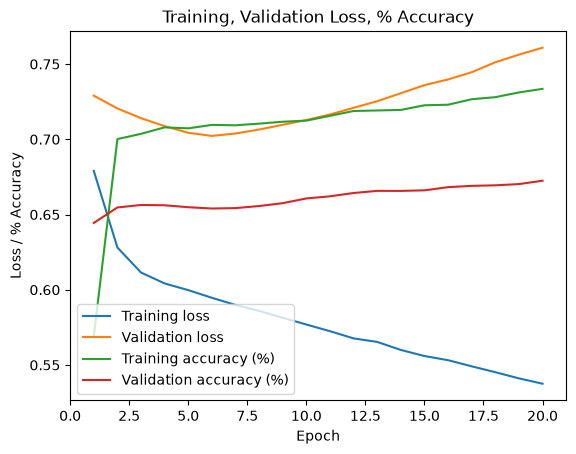

In [59]:
# Plot mean loss per epoch 
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('train_loss','mean')], label='Training loss')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_loss','mean')], label='Validation loss')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('train_acc','mean')], label='Training accuracy (%)')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_acc','mean')], label='Validation accuracy (%)')
ax.set_xlabel('Epoch')
ax.set_ylabel('Loss / % Accuracy')
ax.set_title('Training, Validation Loss, % Accuracy')
ax.set_xlim(0, len(clf_validation_avg_metrics)+1)

ax.legend()
plt.show()

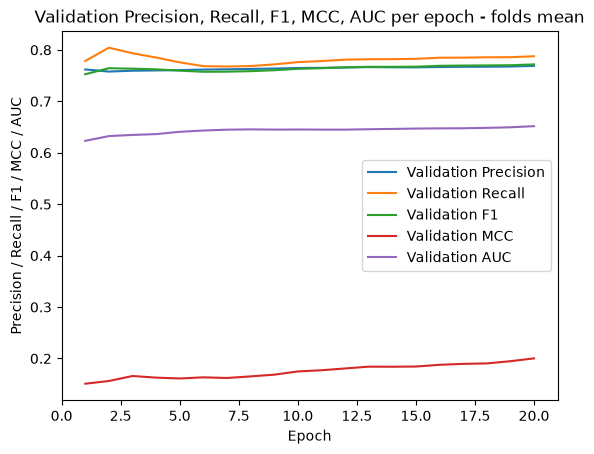

In [61]:
fig = plt.figure()
ax = fig.add_subplot(1, 1, 1)
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_precision','mean')], label='Validation Precision')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_recall','mean')], label='Validation Recall')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_f1','mean')], label='Validation F1')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_mcc','mean')], label='Validation MCC')
ax.plot(range(1, len(clf_validation_avg_metrics)+1), clf_validation_avg_metrics[('val_auc','mean')], label='Validation AUC')
ax.set_xlabel('Epoch')
ax.set_ylabel('Precision / Recall / F1 / MCC / AUC')
ax.set_title('Validation Precision, Recall, F1, MCC, AUC per epoch - folds mean')
ax.set_xlim(0, len(clf_validation_avg_metrics)+1)

ax.legend()
plt.show()

### Predictions on test data

- Predictions using the fine tuned ESM2 model as embedder, then classify tokens using pre-trained (lower level data) classifier 

In [62]:
# Preprocess training data
test_df = pd.read_csv(target)

# Mask n/a values with -100 
test_df['Class'] = test_df['Class'].fillna(-100).astype('int32')
test_df['Class'] = test_df['Class'].replace(-1, 0)

# Sort values before aggregation
test_df = test_df.sort_values(['Info_protein_id', 'Info_pos'])

# Aggregate columns for wide format
test_df = test_df.groupby(['Info_protein_id'], as_index=False).agg( 
    sequence=('Info_AA', ''.join), 
    label=('Class', list), 
    position=('Info_pos', list))

# Apply sliding window
test_df = sliding_window(test_df)

# Delete rows 
test_df = delete_unlabelled_rows(test_df)

# Create datasets
test_datasets = SequenceDataset(test_df)

# Create batches
test_batched = batch_create(test_datasets, tokenizer, model)


Evaluate using pretrained classifier

In [63]:
# Instantiate new model
clf = PerResidueClassifier().to(device)

# Load trained model
checkpoint_data = torch.load(f'/home/ubuntu/output/{checkpoint[9:]}_{run}_final_classifier.pt', weights_only=False)

# Load trained weights
clf.load_state_dict(checkpoint_data['model_state_dict'])

# Put classifier into evaluation mode
clf.eval()

test_preds = []
test_labels = []
test_probs = []

with torch.no_grad():
    
    for batch in test_batched:
        outputs = clf(batch['embeddings'].to(device))

    labels = batch['labels'].reshape(-1).to(device)
    
    # Calculate preds and probs
    preds = torch.argmax(outputs, dim=-1).reshape(-1)
    probs = torch.softmax(outputs, dim=-1)[:, :, 1].reshape(-1)
    
    test_preds.append(preds)
    test_labels.append(labels)
    test_probs.append(probs)

# Concat tensors
test_preds = torch.cat(test_preds)
test_labels = torch.cat(test_labels)
test_probs = torch.cat(test_probs)

mask = test_labels != -100

test_preds = test_preds[mask].cpu().numpy()
test_labels = test_labels[mask].cpu().numpy()
test_probs = test_probs[mask].cpu().numpy()

# Calculate metrics
accuracy = accuracy_score(test_labels, test_preds)
precision = precision_score(test_labels, test_preds)
recall = recall_score(test_labels, test_preds)
f1 = f1_score(test_labels, test_preds)
mcc = matthews_corrcoef(test_labels, test_preds)
auc = roc_auc_score(test_labels, test_probs)

In [64]:
# Create pandas dataframe
data = { 'Accuracy':accuracy, 'Precision':precision, 'Recall':recall, 'F1':f1, 'mcc':mcc, 'auc':auc}

test_results = pd.DataFrame(data, index=np.array(np.arange(1,2)))

# Save to csv
test_results.to_csv(f'{S3}{checkpoint[9:]}_{run}_test_predictions.csv')

test_results 

,Accuracy,Precision,Recall,F1,mcc,auc
1,0.633621,0.548454,0.687339,0.610092,0.278901,0.678784


In [71]:
model.load_state_dict

<bound method Module.load_state_dict of EsmForTokenClassification(
  (esm): EsmModel(
    (embeddings): EsmEmbeddings(
      (word_embeddings): Embedding(33, 320, padding_idx=1)
      (dropout): Dropout(p=0.0, inplace=False)
      (position_embeddings): Embedding(1026, 320, padding_idx=1)
    )
    (encoder): EsmEncoder(
      (layer): ModuleList(
        (0-5): 6 x EsmLayer(
          (attention): EsmAttention(
            (self): EsmSelfAttention(
              (query): Linear(in_features=320, out_features=320, bias=True)
              (key): Linear(in_features=320, out_features=320, bias=True)
              (value): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
              (rotary_embeddings): RotaryEmbedding()
            )
            (output): EsmSelfOutput(
              (dense): Linear(in_features=320, out_features=320, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
            (Lay